# Срез по первому модулю

## Импорт нужных библиотек

In [339]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, HDBSCAN, DBSCAN
from sklearn.decomposition import PCA

import seaborn as sb

## Задание 1.1. Создание объекта класса DataFrame с нашим "грязным" датасетом. Загружаем его в базу данных и проводим первичную очистку

### Записываем объект в переменную data для дальнейшей работы с ним

In [340]:
data = pd.read_csv("data.csv")

In [341]:
data = data.drop("Unnamed: 32", axis=1)

In [342]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Создаем базу данных и записываем в нее датасет

In [343]:
conn = sqlite3.connect('test_db.db')
data.to_sql('user', conn, if_exists='replace', index=False)

569

### Заменяем все строковые значения в датасете на цифры, для более удобного использования его в моделях

#### Так же проверяем на пустые значения или NaN

In [344]:
data.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [345]:
data["diagnosis"].unique()

array(['M', 'B'], dtype=object)

In [346]:
data["diagnosis"] = data["diagnosis"].map({'M': 0, 'B': 1})

## Задание 1.2. Поиск модели для разбиения значений на кластеры, выбор модели и визуализация кластеров

### Изменяем формат датасета для использования его доя обучения модели

In [347]:
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

### Обучем 3 модели для кластеризации, проводим через них датасет и визуализируем результат

In [348]:
km = KMeans(n_clusters=3)
hb = HDBSCAN()
db = DBSCAN()

In [349]:
km.fit(data_2d)

C:\Users\demoexam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans(n_clusters=3)

In [350]:
hb.fit(data_2d)

HDBSCAN()

In [351]:
db.fit(data_2d)

DBSCAN()

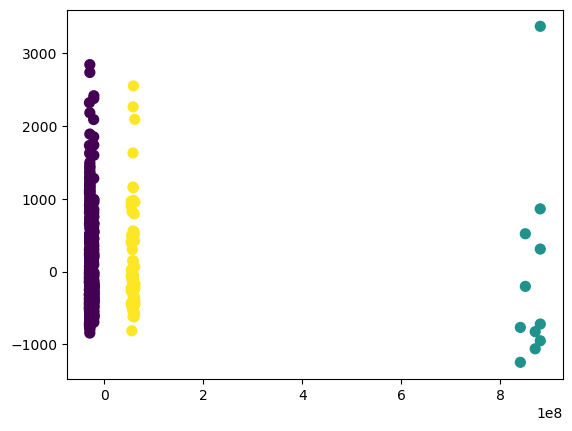

In [352]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=km.labels_, s=50, cmap='viridis')

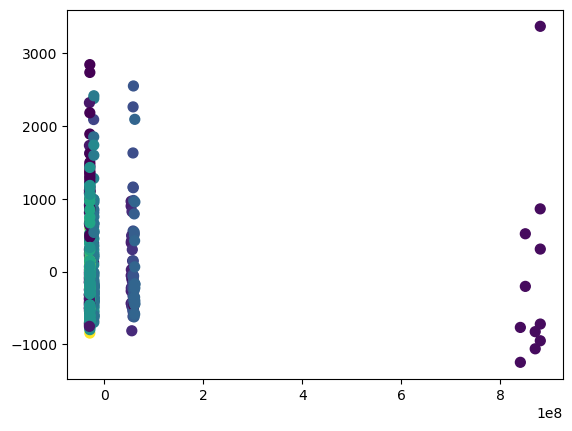

In [353]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=hb.labels_, s=50, cmap='viridis')

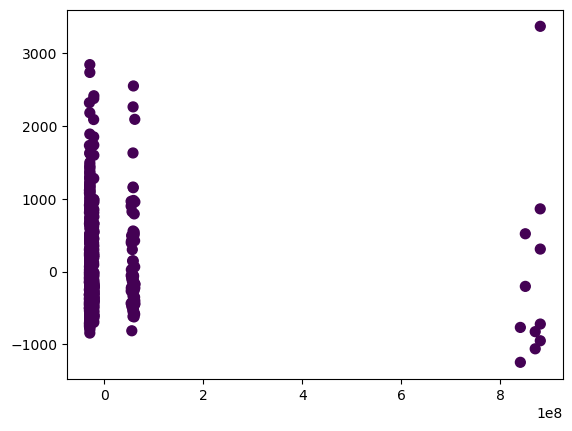

In [354]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=db.labels_, s=50, cmap='viridis')

#### Модель KMeans лучше всех поделила данные на кластеры, они не пересекаются и четко разделены на группы

### Получаем значения модели и объединяем их с датасетом

In [355]:
km_pred = km.fit_predict(data)

C:\Users\demoexam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [356]:
km_pred = pd.Series(km_pred) # Преобразуем значения в Series для удобного объединения с таблицей

In [357]:
km_pred.name = "claster" # Даем название для будущего столбца
km_pred.index = km_pred.index # Делаем у них одинаковые индексы

In [358]:
km_pred

0      2
1      2
2      0
3      0
4      0
      ..
564    2
565    2
566    2
567    2
568    2
Name: claster, Length: 569, dtype: int32

In [359]:
data["claster"] = km_pred

In [360]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,claster
0,842302,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,2
1,842517,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,2
2,84300903,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,84348301,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,84358402,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,0,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,2
565,926682,0,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,2
566,926954,0,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,2
567,927241,0,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,2


## Задание 1.5. Обучаем простую модель и смотрим, какие данные она использует. После, сравнивая с матрицей корреляции, удаляем не нужные атрибуты

In [361]:
tree_model = DecisionTreeClassifier()

### Подготавливаем данные

In [362]:
y = data["diagnosis"]

In [363]:
X = data.drop("diagnosis", axis=1)

In [364]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5, random_state=42)

### Обучаем модель и получаем коэффиценты

In [365]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [366]:
tree_model.feature_importances_ # Коэффиценты, на сколько ей пригодились атрибуты во время обучения

array([0.04835913, 0.        , 0.01450003, 0.        , 0.        ,
       0.01449839, 0.        , 0.        , 0.02198142, 0.01758514,
       0.        , 0.        , 0.        , 0.        , 0.02271852,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.1234607 ,
       0.        , 0.        , 0.02512163, 0.71177504, 0.        ,
       0.        , 0.        ])

### Получаем данные для матрицы корреляции и визуализируем ее (было визуализированно две, так как на одной не помещались все данные)

In [367]:
cor = data.iloc[:, :-20].corr()

<Axes: >

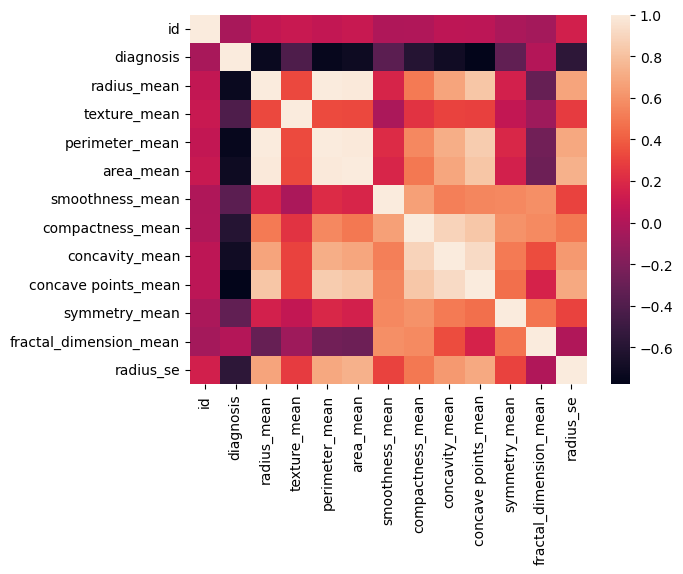

In [368]:
sb.heatmap(cor)

In [369]:
cor = data.iloc[:, 20:].corr()

<Axes: >

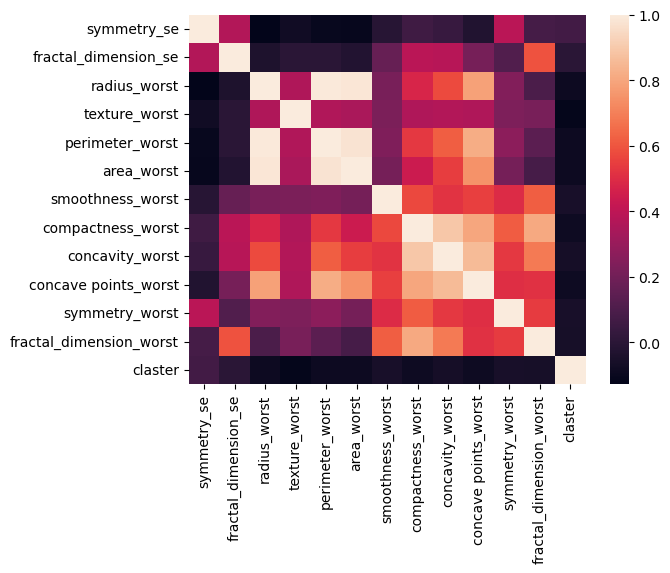

In [370]:
sb.heatmap(cor)

### Удаляем атрибуты, коэффицент которых равен 0, то есть они почти совсем не использовались при обучении. Исключением составляет атрибут "claster", так как он понадовится в будущих заданиях

In [371]:
data = data.drop(X_train.columns[tree_model.feature_importances_ == 0], axis=1)

In [372]:
data["claster"] = km_pred

In [373]:
data

,id,diagnosis,texture_mean,smoothness_mean,concave points_mean,symmetry_mean,area_se,area_worst,concavity_worst,concave points_worst,claster
0,842302,0,10.38,0.11840,0.14710,0.2419,153.40,2019.0,0.7119,0.2654,2
1,842517,0,17.77,0.08474,0.07017,0.1812,74.08,1956.0,0.2416,0.1860,2
2,84300903,0,21.25,0.10960,0.12790,0.2069,94.03,1709.0,0.4504,0.2430,0
3,84348301,0,20.38,0.14250,0.10520,0.2597,27.23,567.7,0.6869,0.2575,0
4,84358402,0,14.34,0.10030,0.10430,0.1809,94.44,1575.0,0.4000,0.1625,0
...,...,...,...,...,...,...,...,...,...,...,...
564,926424,0,22.39,0.11100,0.13890,0.1726,158.70,2027.0,0.4107,0.2216,2
565,926682,0,28.25,0.09780,0.09791,0.1752,99.04,1731.0,0.3215,0.1628,2
566,926954,0,28.08,0.08455,0.05302,0.1590,48.55,1124.0,0.3403,0.1418,2
567,927241,0,29.33,0.11780,0.15200,0.2397,86.22,1821.0,0.9387,0.2650,2


### Сохраняем чистый датасет в базу данных

In [374]:
data.to_sql('clean_dataset', conn, if_exists='replace', index=False)

569

## Задание 1.3. Создаем информационную таблицу в отдельной программе, смотрим ее и визуализируем данные, смотроя на их распределение

### Смотрим информационную таблицу

In [375]:
inf_table = pd.read_csv("information_table.csv")

In [378]:
inf_table = inf_table.drop("Unnamed: 5", axis=1)

In [379]:
inf_table

,Название столбца,Перевод,Описание,Тип данных,Еидиница измерения
0,id,Порядковый номер,Номер опухоли,Целочисленный,-
1,diagnosis,Диагноз,Итоговый диагноз,Число с плавующей точкой,-
2,texture_mean,Обозначение текстуры,На сколько текстура влияет на диагноз,Число с плавующей точкой,-
3,smoothness_mean,Обозначение гладкости,На сколько гладкость влияет на диагноз,Число с плавующей точкой,-
4,concave points_mean,Обозначение вогнутых точек,На сколько вогнутость точек влияет на диагноз,Число с плавующей точкой,-
5,symmetry_mean,Значение симметрии,На сколько счимметрия влияет на диагноз,Число с плавующей точкой,-
6,area_se,Стандартная ошибка размера опухоли,Стандартное отклонение от размеров,Число с плавующей точкой,-
7,concavity_worst,Высокая вогнутость,На сколько влияет высокая вогнутость на диагноз,Число с плавующей точкой,-
8,concave points_worst,Точки высокой вогнутости,Точки с высокой вогнутостью,Число с плавующей точкой,-
9,claster,Кластеры,Группа кластеров,Целочисленный,-


### Строим диограммы всех атрибутов, чтобы понять их распределние

In [380]:
data

,id,diagnosis,texture_mean,smoothness_mean,concave points_mean,symmetry_mean,area_se,area_worst,concavity_worst,concave points_worst,claster
0,842302,0,10.38,0.11840,0.14710,0.2419,153.40,2019.0,0.7119,0.2654,2
1,842517,0,17.77,0.08474,0.07017,0.1812,74.08,1956.0,0.2416,0.1860,2
2,84300903,0,21.25,0.10960,0.12790,0.2069,94.03,1709.0,0.4504,0.2430,0
3,84348301,0,20.38,0.14250,0.10520,0.2597,27.23,567.7,0.6869,0.2575,0
4,84358402,0,14.34,0.10030,0.10430,0.1809,94.44,1575.0,0.4000,0.1625,0
...,...,...,...,...,...,...,...,...,...,...,...
564,926424,0,22.39,0.11100,0.13890,0.1726,158.70,2027.0,0.4107,0.2216,2
565,926682,0,28.25,0.09780,0.09791,0.1752,99.04,1731.0,0.3215,0.1628,2
566,926954,0,28.08,0.08455,0.05302,0.1590,48.55,1124.0,0.3403,0.1418,2
567,927241,0,29.33,0.11780,0.15200,0.2397,86.22,1821.0,0.9387,0.2650,2


<Axes: xlabel='texture_mean', ylabel='Count'>

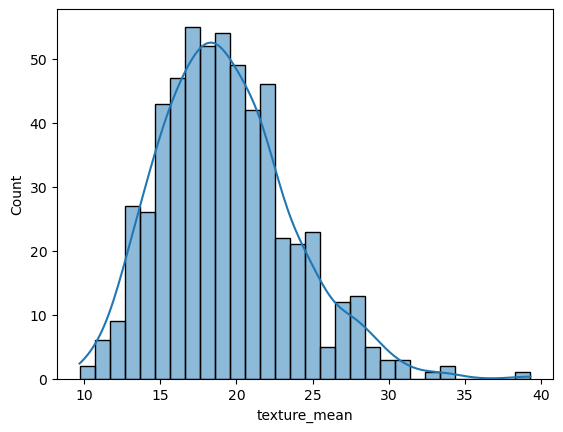

In [382]:
sb.histplot(data=data, x="texture_mean", bins=30, kde=True) # Распределение нормальное

<Axes: xlabel='smoothness_mean', ylabel='Count'>

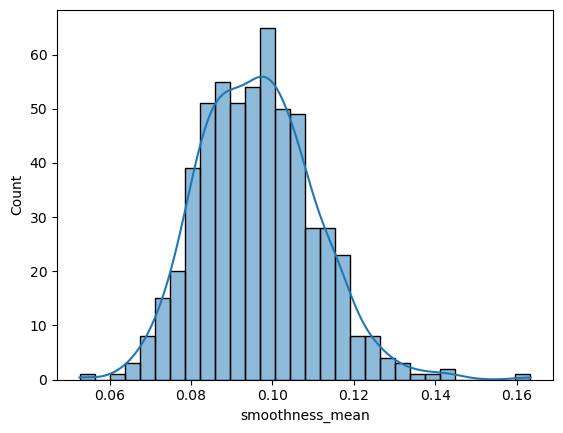

In [383]:
sb.histplot(data=data, x="smoothness_mean", bins=30, kde=True) # Распределение нормальное

<Axes: xlabel='concave points_mean', ylabel='Count'>

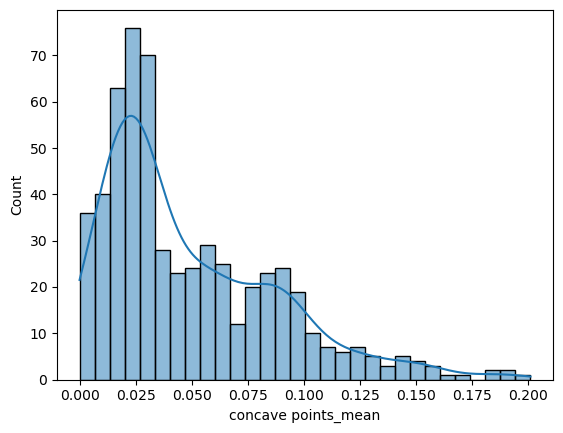

In [384]:
sb.histplot(data=data, x="concave points_mean", bins=30, kde=True) # Распределение логнормальное с положительным отклонением

<Axes: xlabel='symmetry_mean', ylabel='Count'>

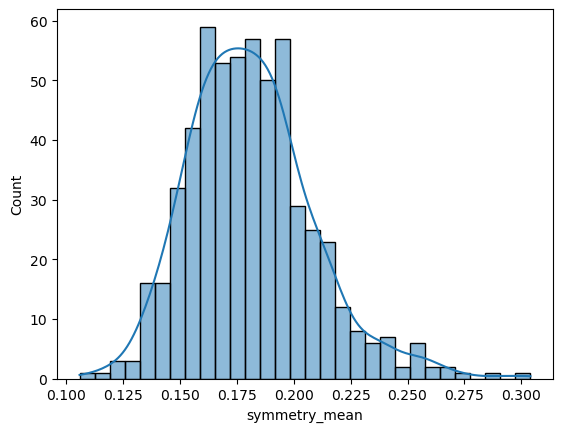

In [385]:
sb.histplot(data=data, x="symmetry_mean", bins=30, kde=True) # Распределение логнормальное с положительным отклонением

<Axes: xlabel='area_se', ylabel='Count'>

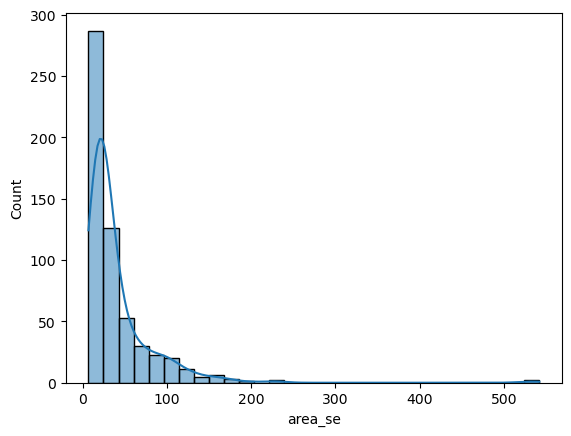

In [386]:
sb.histplot(data=data, x="area_se", bins=30, kde=True) # Гамма-распределение с положительным отклонением

<Axes: xlabel='area_worst', ylabel='Count'>

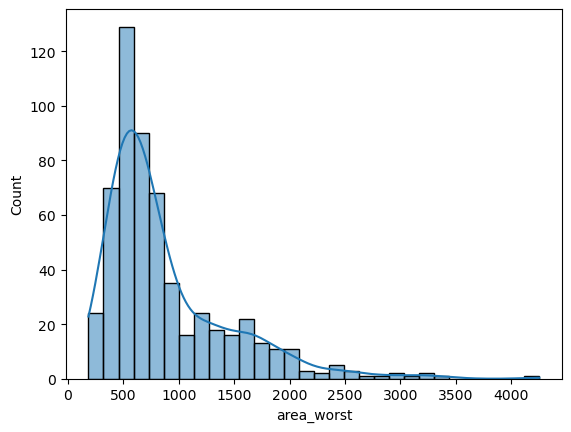

In [387]:
sb.histplot(data=data, x="area_worst", bins=30, kde=True) # Распределение логнормальное с положительным отклонением

<Axes: xlabel='concavity_worst', ylabel='Count'>

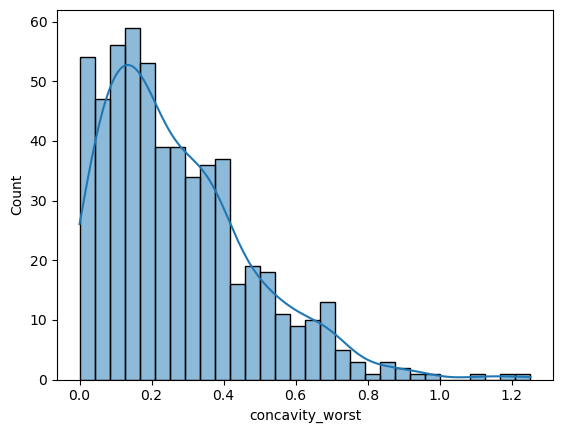

In [388]:
sb.histplot(data=data, x="concavity_worst", bins=30, kde=True) # Распределение логнормальное с положительным отклонением

<Axes: xlabel='concave points_worst', ylabel='Count'>

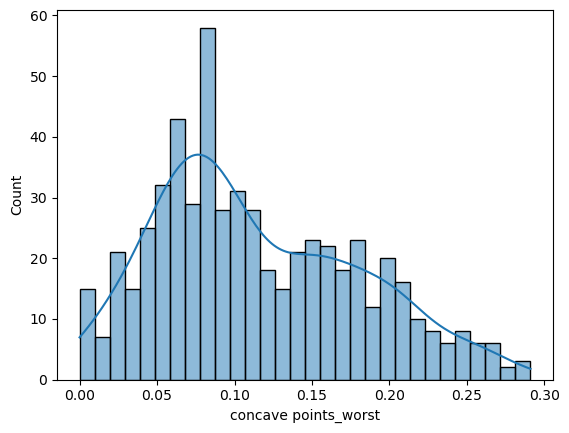

In [389]:
sb.histplot(data=data, x="concave points_worst", bins=30, kde=True) # Вейбула

## Задание 1.4

### Я импортирую старый датасет, т.к в чистом уже нету этих данных (уже почистил)

In [390]:
data_copy = pd.read_csv("data.csv")

In [402]:
data_copy

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


### Задание 1.4.1

In [397]:
data_copy.groupby("diagnosis")["texture_se"].mean()

diagnosis
B    1.220380
M    1.210915
Name: texture_se, dtype: float64

### Задание 1.4.2

In [417]:
data_copy[["area_se", "perimeter_se"]].sum(axis=1) + data_copy["texture_se"].mean()

0      163.205853
1       78.694853
2       99.831853
3       31.891853
4      101.094853
          ...    
564    167.589853
565    105.459853
566     53.191853
567     93.208853
568     22.914853
Length: 569, dtype: float64

### Задание 1.4.3

In [433]:
for i, r in data_copy.iterrows():
    if r["diagnosis"] == "B":
        print(i,") ", r["texture_se"] * r["area_se"])
    else:
        print(i,") ", r["texture_se"] + r["area_se"])

0 )  154.30530000000002
1 )  74.8139
2 )  94.8169
3 )  28.386
4 )  95.2213
5 )  28.0802
6 )  54.6832
7 )  52.337
8 )  25.322
9 )  25.539
10 )  41.696999999999996
11 )  55.1449
12 )  119.768
13 )  37.658
14 )  20.379
15 )  33.583
16 )  46.64
17 )  55.253
18 )  113.417
19 )  18.579416
20 )  10.968759
21 )  15.335759999999999
22 )  45.6196
23 )  95.11699999999999
24 )  103.5017
25 )  112.376
26 )  22.0332
27 )  95.38900000000001
28 )  44.512
29 )  61.9225
30 )  106.466
31 )  42.03
32 )  69.178
33 )  68.7762
34 )  35.7157
35 )  46.1097
36 )  25.929
37 )  33.16272
38 )  108.188
39 )  19.1114
40 )  21.3565
41 )  18.398
42 )  106.566
43 )  32.1549
44 )  15.1023
45 )  72.22330000000001
46 )  7.8497235
47 )  25.1437
48 )  14.493178000000002
49 )  27.330599999999997
50 )  34.448699999999995
51 )  13.43547
52 )  11.056763
53 )  100.403
54 )  30.7439
55 )  22.510077
56 )  103.693
57 )  41.24
58 )  40.01344
59 )  4.8234312
60 )  49.88742
61 )  38.012130000000006
62 )  62.048
63 )  53.27280000000000